<a href="https://colab.research.google.com/github/basketball192/Real-NFL-Research-6-2026/blob/main/NFL_Research_DSRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import everything

In [4]:
file_path = "/content/nfl_games.csv"
nfl_games = pd.read_csv(file_path)

nfl_games.head()

#Load file and check the data set

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,...,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,...,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,...,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,...,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,...,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [5]:
nfl_games.info() #get basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7548 entries, 0 to 7547
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7548 non-null   object 
 1   season            7548 non-null   int64  
 2   game_type         7548 non-null   object 
 3   week              7548 non-null   int64  
 4   gameday           7548 non-null   object 
 5   weekday           7548 non-null   object 
 6   gametime          7289 non-null   object 
 7   away_team         7548 non-null   object 
 8   away_score        7276 non-null   float64
 9   home_team         7548 non-null   object 
 10  home_score        7276 non-null   float64
 11  location          7548 non-null   object 
 12  result            7276 non-null   float64
 13  total             7276 non-null   float64
 14  overtime          7276 non-null   float64
 15  old_game_id       7548 non-null   int64  
 16  gsis              7276 non-null   float64


In [6]:
poop = nfl_games[nfl_games["pff"].isna()]
pd.value_counts(poop["season"])

# check what years the NANs are


/tmp/ipykernel_1717/3250306560.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(poop["season"])


,count
season,
2023,285
2024,285
2022,284
2026,272
2005,267
2004,267
2003,267
2002,267
2001,259


In [14]:
pd.value_counts(nfl_games["espn"]) # check unique values for poteitally useless columns

/tmp/ipykernel_1717/225620066.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(nfl_games["espn"]) # check unique values for poteitally useless columns


,count
espn,
231027024.0,3
230921017.0,2
261119015.0,2
250102017.0,2
231228001.0,2
...,...
280928020.0,1
280928018.0,1
280928012.0,1


DAY 2 WORK

In [40]:
nfl_updated = nfl_games.drop(columns = ['nfl_detail_id', 'away_qb_id', 'home_qb_id', 'stadium_id','old_game_id','pfr', 'ftn', 'espn', 'pff', 'gsis'])

#take out useless columns

In [41]:
nfl_updated = nfl_updated[nfl_updated['season']<2026]

nfl_updated.info() #take out 2026 season

<class 'pandas.core.frame.DataFrame'>
Index: 7276 entries, 0 to 7275
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_id           7276 non-null   object 
 1   season            7276 non-null   int64  
 2   game_type         7276 non-null   object 
 3   week              7276 non-null   int64  
 4   gameday           7276 non-null   object 
 5   weekday           7276 non-null   object 
 6   gametime          7017 non-null   object 
 7   away_team         7276 non-null   object 
 8   away_score        7276 non-null   float64
 9   home_team         7276 non-null   object 
 10  home_score        7276 non-null   float64
 11  location          7276 non-null   object 
 12  result            7276 non-null   float64
 13  total             7276 non-null   float64
 14  overtime          7276 non-null   float64
 15  away_rest         7276 non-null   int64  
 16  home_rest         7276 non-null   int64  
 17  

In [42]:


poop = nfl_updated[nfl_updated["under_odds"].isna()]
pd.value_counts(poop["season"]) # see where NAns are

/tmp/ipykernel_1717/1455447901.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(poop["season"]) # see where NAns are


,count
season,
2002,267
2005,267
2004,267
2003,267
2001,259
2000,259
1999,259
2008,73
2006,50


In [43]:
nfl_updated = nfl_updated.rename(columns={'game_id':'Game ID',
                                 'season':'Season',
                                 'game_type':'Game Type',
                                 'week':'Week',
                                 'gameday':'Game Day',
                                 'weekday':'Week Day',
                                 'gametime':'Game Time',
                                 'away_team':'Away Team',
                                 'away_score':'Away Score',
                                 'home_team':'Home Team',
                                 'home_score':'Home Score',
                                 'location':'Location',
                                 'result':'Result',
                                 'total':'Total',
                                 'overtime':'Overtime',

                                 'away_rest':'Away Rest',
                                 'home_rest':'Home Rest',
                                 'away_moneyline':'Away Moneyline',
                                 'home_moneyline':'Home Moneyline',
                                 'spread_line':'Spread Line',
                                 'away_spread_odds':'Away Spread Odds',
                                 'home_spread_odds':'Home Spread Odds',
                                 'total_line':'Total line',
                                 'under_odds':'Under Odds',
                                 'over_odds':'Over Odds',
                                 'div_game':'Division Game',
                                 'roof':'Roof',
                                 'surface':'Surface',
                                 'temp':'Temperature',
                                 'wind':'Wind',
                                 'away_qb_name':'Away QB Name',
                                 'home_qb_name':'Home QB Name',
                                 'away_coach':'Away Coach',
                                 'home_coach':'Home Coach',
                                 'referee':'Referee',
                                 'stadium':'Stadium',})


In [44]:
nfl_updated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7276 entries, 0 to 7275
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Game ID           7276 non-null   object 
 1   Season            7276 non-null   int64  
 2   Game Type         7276 non-null   object 
 3   Week              7276 non-null   int64  
 4   Game Day          7276 non-null   object 
 5   Week Day          7276 non-null   object 
 6   Game Time         7017 non-null   object 
 7   Away Team         7276 non-null   object 
 8   Away Score        7276 non-null   float64
 9   Home Team         7276 non-null   object 
 10  Home Score        7276 non-null   float64
 11  Location          7276 non-null   object 
 12  Result            7276 non-null   float64
 13  Total             7276 non-null   float64
 14  Overtime          7276 non-null   float64
 15  Away Rest         7276 non-null   int64  
 16  Home Rest         7276 non-null   int64  
 17  

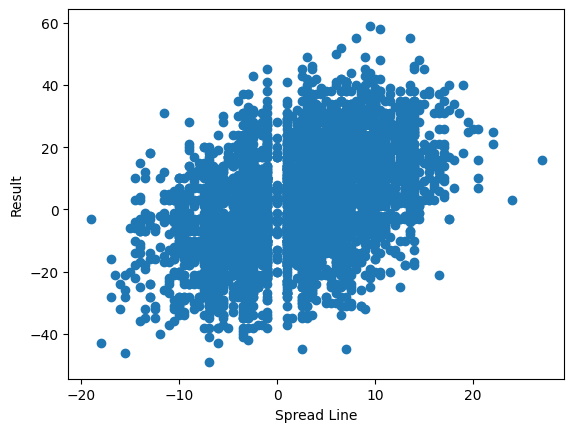

In [49]:
plt.scatter(nfl_updated["Spread Line"], nfl_updated["Result"])

plt.xlabel("Spread Line")
plt.ylabel("Result")

plt.show()